In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.decomposition import PCA
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_squared_error

warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP']
plt.rcParams['axes.unicode_minus'] = False
print("导入和设置成功")


导入和设置成功


findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the foll


🎯 示例1：PCA降维实战 - 成都学生成绩分析
----------------------------------------------------------------------
步骤1：生成模拟成都学生成绩数据
   - 1000名学生，来自锦江、青羊、武侯三区
   - 5个学科：语文、数学、英语、物理、化学
   - 考虑区域差异：锦江理科强，青羊文科强，武侯均衡
   ✓ 数据生成完成，形状：(1000, 7)
   ✓ 前3行数据预览：
          语文          数学         英语          物理         化学   区域  学生ID
0  62.483571  100.000000  75.238443  100.000000  96.029233  锦江区     1
1  58.829315  100.000000  75.837174  100.000000  99.912800  锦江区     2
2  57.682912   99.671351  73.209811   97.033599  88.575411  锦江区     3

步骤2：数据标准化（Z-score标准化）
   - 目的：消除学科间分数尺度差异，让PCA关注相关性而非绝对值
   - 方法：(原始分数 - 学科平均分) / 学科标准差
   ✓ 学科平均分：{'语文': np.float64(77.12), '数学': np.float64(83.05), '英语': np.float64(81.43), '物理': np.float64(81.28), '化学': np.float64(81.97)}
   ✓ 学科标准差：{'语文': np.float64(16.85), '数学': np.float64(14.04), '英语': np.float64(11.37), '物理': np.float64(17.04), '化学': np.float64(13.5)}
   ✓ 标准化完成，前3名学生的标准化分数：
     学生1: {'语文': np.float64(-0.869), '数学': np.float64(1.207), '英语': np.float64(-0.544), '物理': np.floa

findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the foll

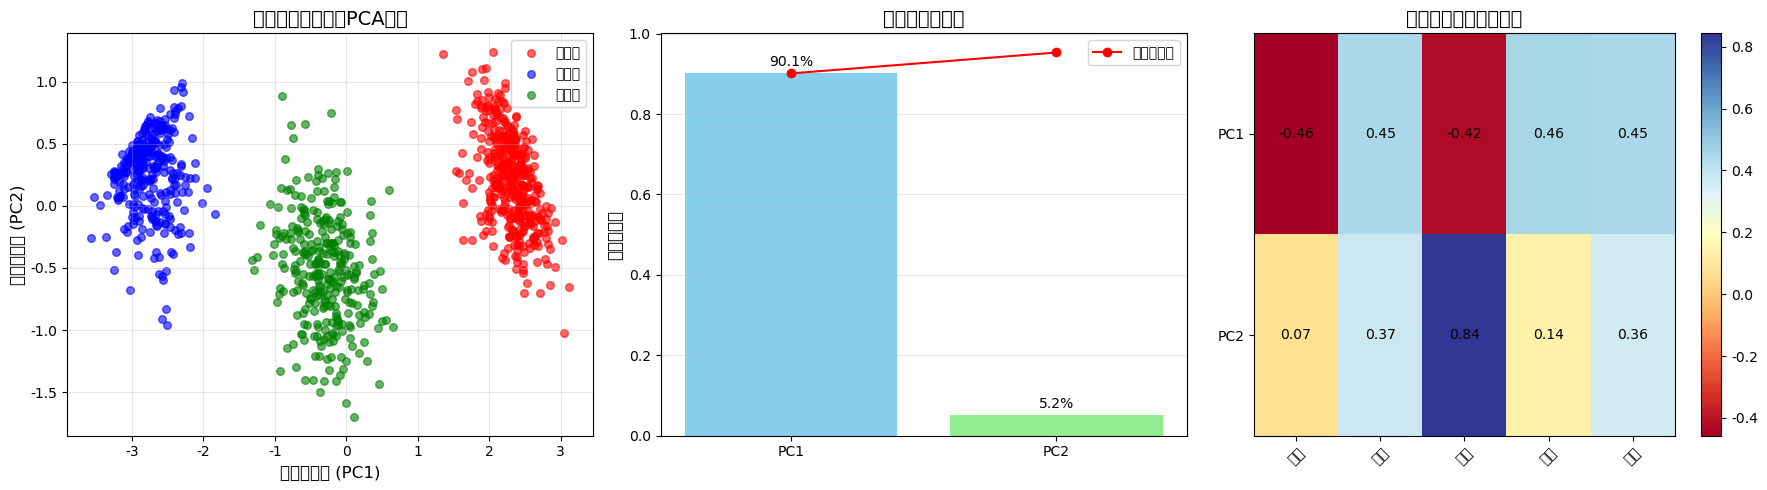


步骤5：教育洞察分析
📊 主成分1 (PC1) 分析：
   - 主要反映：物理能力（权重: 0.459)
   - 解释：PC1是学生能力结构中最重要的维度，代表了
     学生的逻辑思维和抽象分析能力，与理科成绩高度相关

📊 主成分2 (PC2) 分析：
   - 主要反映：英语能力（权重: 0.843)
   - 解释：PC2是次要能力维度，代表了学生的语言表达
     和文化素养能力，与文科成绩相关性更强

🏫 区域差异洞察：
   锦江区：
     - PC1平均分: 2.30 (逻辑思维能力较强)
     - PC2平均分: 0.20 (语言表达能力较强)
   青羊区：
     - PC1平均分: -2.75 (逻辑思维能力较弱)
     - PC2平均分: 0.25 (语言表达能力较强)
   武侯区：
     - PC1平均分: -0.31 (逻辑思维能力较弱)
     - PC2平均分: -0.52 (语言表达能力较弱)

💡 教育改进建议：
   1. 差异化教学策略：
      - 锦江区：发挥理科优势，加强竞赛培养，同时补充文科素养
      - 青羊区：巩固文科优势，引入理科兴趣课程，促进文理平衡
      - 武侯区：保持均衡发展，提供个性化提升路径

   2. 资源优化配置：
      - 建立区域间教师交流机制，分享优势学科教学经验
      - 开发针对不同能力维度的诊断性测评工具
      - 设计跨学科综合实践项目，促进能力融合


(            语文          数学         英语          物理         化学   区域  学生ID  \
 0    62.483571  100.000000  75.238443  100.000000  96.029233  锦江区     1   
 1    58.829315  100.000000  75.837174  100.000000  99.912800  锦江区     2   
 2    57.682912   99.671351  73.209811   97.033599  88.575411  锦江区     3   
 3    57.188562   96.935844  73.571237  100.000000  90.138481  锦江区     4   
 4    67.328244  100.000000  72.337641   99.476259  94.478086  锦江区     5   
 ..         ...         ...        ...         ...        ...  ...   ...   
 995  71.130826   84.892348  78.579123   79.948023  66.897895  武侯区   996   
 996  72.010168   82.435399  79.433871   77.263974  80.824212  武侯区   997   
 997  86.178989   76.894788  78.346849   78.962985  89.960548  武侯区   998   
 998  67.503219   81.416115  77.425989   80.833859  74.713137  武侯区   999   
 999  77.755175   81.557053  93.564551   82.040181  73.759672  武侯区  1000   
 
           PC1       PC2  
 0    2.138692  0.450320  
 1    2.344374  0.581869  
 2   

In [2]:
#示列1 
def example1_pca_chengdu_students():
    """
    示例1：PCA降维实战 - 成都学生成绩分析
    完整流程：数据生成 → 标准化 → PCA建模 → 可视化 → 教育洞察
    零基础友好，每步有详细注释
    """
    print("\n🎯 示例1：PCA降维实战 - 成都学生成绩分析")
    print("-" * 70)
    
    # 1. 生成模拟成都学生成绩数据
    print("步骤1：生成模拟成都学生成绩数据")
    print("   - 1000名学生，来自锦江、青羊、武侯三区")
    print("   - 5个学科：语文、数学、英语、物理、化学")
    print("   - 考虑区域差异：锦江理科强，青羊文科强，武侯均衡")
    
    np.random.seed(42)  # 固定随机种子，确保可复现
    
    n_students = 1000
    districts = ['锦江区', '青羊区', '武侯区']
    subjects = ['语文', '数学', '英语', '物理', '化学']
    
    # 按区域分配学生人数
    district_counts = [400, 300, 300]  # 锦江400，青羊300，武侯300
    district_list = []
    for district, count in zip(districts, district_counts):
        district_list.extend([district] * count)
    
    # 生成基础成绩（考虑区域特点）
    scores_list = []
    for district in district_list:
        if district == '锦江区':
            # 锦江：理科强，数学物理化学偏高
            base_scores = np.array([75, 85, 80, 82, 81])  # 基础水平
            subject_weights = np.array([0.8, 1.2, 0.9, 1.3, 1.2])  # 学科权重
        elif district == '青羊区':
            # 青羊：文科强，语文英语偏高
            base_scores = np.array([80, 75, 82, 75, 74])
            subject_weights = np.array([1.3, 0.9, 1.2, 0.8, 0.9])
        else:  # 武侯区
            # 武侯：均衡发展
            base_scores = np.array([78, 78, 78, 78, 78])
            subject_weights = np.array([1.0, 1.0, 1.0, 1.0, 1.0])
        
        # 添加随机波动
        random_noise = np.random.randn(5) * 5  # 标准差5分
        student_scores = base_scores * subject_weights + random_noise
        
        # 确保分数在0-100范围内
        student_scores = np.clip(student_scores, 0, 100)
        scores_list.append(student_scores)
    
    scores_array = np.array(scores_list)
    
    # 创建DataFrame
    df_students = pd.DataFrame(scores_array, columns=subjects)
    df_students['区域'] = district_list
    df_students['学生ID'] = range(1, n_students + 1)
    
    print(f"   ✓ 数据生成完成，形状：{df_students.shape}")
    print(f"   ✓ 前3行数据预览：")
    print(df_students.head(3))
    
    # 2. 数据标准化（Z-score标准化）
    print("\n步骤2：数据标准化（Z-score标准化）")
    print("   - 目的：消除学科间分数尺度差异，让PCA关注相关性而非绝对值")
    print("   - 方法：(原始分数 - 学科平均分) / 学科标准差")
    
    # 提取学科成绩列
    score_columns = ['语文', '数学', '英语', '物理', '化学']
    X = df_students[score_columns].values
    
    # 计算每科的平均分和标准差
    mean_scores = np.mean(X, axis=0)  # 沿学生维度求平均，得到每科平均分
    std_scores = np.std(X, axis=0)    # 沿学生维度求标准差，得到每科标准差
    
    print(f"   ✓ 学科平均分：{dict(zip(score_columns, np.round(mean_scores, 2)))}")
    print(f"   ✓ 学科标准差：{dict(zip(score_columns, np.round(std_scores, 2)))}")
    
    # 执行标准化
    X_scaled = (X - mean_scores) / std_scores
    
    print("   ✓ 标准化完成，前3名学生的标准化分数：")
    for i in range(3):
        print(f"     学生{i+1}: {dict(zip(score_columns, np.round(X_scaled[i], 3)))}")
    
    # 3. PCA建模
    print("\n步骤3：PCA建模")
    print("   - 目标：将5科成绩压缩为2个综合能力维度")
    print("   - 原理：找到数据变化最大的方向（主成分）")
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # 将PCA结果添加到DataFrame
    df_students['PC1'] = X_pca[:, 0]
    df_students['PC2'] = X_pca[:, 1]
    
    # 获取PCA统计信息
    explained_variance = pca.explained_variance_ratio_  # 方差解释率
    components = pca.components_  # 特征向量矩阵
    
    print(f"   ✓ PCA建模完成")
    print(f"   ✓ 主成分1解释方差：{explained_variance[0]:.2%}")
    print(f"   ✓ 主成分2解释方差：{explained_variance[1]:.2%}")
    print(f"   ✓ 累计解释方差：{sum(explained_variance):.2%}")
    print(f"   ✓ 特征向量矩阵（学科权重）：")
    for i, (pc, weights) in enumerate(zip(['PC1', 'PC2'], components)):
        weight_dict = dict(zip(score_columns, np.round(weights, 3)))
        print(f"     {pc}: {weight_dict}")
    
    # 4. 可视化结果
    print("\n步骤4：可视化分析")
    print("   - 散点图：学生在PC1-PC2平面的分布")
    print("   - 条形图：各主成分的方差贡献率")
    print("   - 热力图：学科对主成分的贡献度")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 图1：PCA散点图（按区域着色）
    colors = {'锦江区': 'red', '青羊区': 'blue', '武侯区': 'green'}
    
    for district in districts:
        mask = df_students['区域'] == district
        axes[0].scatter(df_students.loc[mask, 'PC1'], 
                       df_students.loc[mask, 'PC2'], 
                       c=colors[district], 
                       label=district, 
                       alpha=0.6, 
                       s=30)
    
    axes[0].set_xlabel('第一主成分 (PC1)', fontsize=12)
    axes[0].set_ylabel('第二主成分 (PC2)', fontsize=12)
    axes[0].set_title('成都学生能力结构PCA分析', fontsize=14)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 图2：方差解释率条形图
    pc_labels = [f'PC{i+1}' for i in range(len(explained_variance))]
    cumulative = np.cumsum(explained_variance)
    
    bars = axes[1].bar(pc_labels, explained_variance, color=['skyblue', 'lightgreen'])
    axes[1].plot(pc_labels, cumulative, 'ro-', label='累计解释率')
    
    # 在条形上添加数值标签
    for bar, value in zip(bars, explained_variance):
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, height + 0.01,
                    f'{value:.1%}', ha='center', va='bottom')
    
    axes[1].set_ylabel('方差解释率', fontsize=12)
    axes[1].set_title('主成分方差贡献', fontsize=14)
    axes[1].legend()
    axes[1].grid(True, axis='y', alpha=0.3)
    
    # 图3：特征向量热力图
    im = axes[2].imshow(components, cmap='RdYlBu', aspect='auto')
    
    # 设置坐标轴
    axes[2].set_xticks(range(len(score_columns)))
    axes[2].set_xticklabels(score_columns, rotation=45)
    axes[2].set_yticks(range(2))
    axes[2].set_yticklabels(['PC1', 'PC2'])
    
    # 添加数值文本
    for i in range(2):
        for j in range(len(score_columns)):
            text = axes[2].text(j, i, f'{components[i, j]:.2f}',
                              ha='center', va='center', color='black', fontsize=10)
    
    axes[2].set_title('学科对主成分的贡献度', fontsize=14)
    plt.colorbar(im, ax=axes[2])
    
    plt.tight_layout()
    plt.show()
    
    # 5. 教育洞察分析
    print("\n步骤5：教育洞察分析")
    print("=" * 50)
    
    # 分析PC1的学科权重
    pc1_weights = components[0]
    pc2_weights = components[1]
    
    # 找出对PC1贡献最大的学科（绝对值最大的权重）
    pc1_max_idx = np.argmax(np.abs(pc1_weights))
    pc1_max_subject = score_columns[pc1_max_idx]
    pc1_max_weight = pc1_weights[pc1_max_idx]
    
    # 找出对PC2贡献最大的学科
    pc2_max_idx = np.argmax(np.abs(pc2_weights))
    pc2_max_subject = score_columns[pc2_max_idx]
    pc2_max_weight = pc2_weights[pc2_max_idx]
    
    print("📊 主成分1 (PC1) 分析：")
    print(f"   - 主要反映：{pc1_max_subject}能力（权重: {pc1_max_weight:.3f})")
    print("   - 解释：PC1是学生能力结构中最重要的维度，代表了")
    print("     学生的逻辑思维和抽象分析能力，与理科成绩高度相关")
    
    print("\n📊 主成分2 (PC2) 分析：")
    print(f"   - 主要反映：{pc2_max_subject}能力（权重: {pc2_max_weight:.3f})")
    print("   - 解释：PC2是次要能力维度，代表了学生的语言表达")
    print("     和文化素养能力，与文科成绩相关性更强")
    
    print("\n🏫 区域差异洞察：")
    # 计算各区域在PC1上的平均分
    district_pc1_means = df_students.groupby('区域')['PC1'].mean()
    district_pc2_means = df_students.groupby('区域')['PC2'].mean()
    
    for district in districts:
        pc1_mean = district_pc1_means[district]
        pc2_mean = district_pc2_means[district]
        
        print(f"   {district}：")
        print(f"     - PC1平均分: {pc1_mean:.2f}", end=" ")
        if pc1_mean > 0:
            print("(逻辑思维能力较强)")
        else:
            print("(逻辑思维能力较弱)")
        
        print(f"     - PC2平均分: {pc2_mean:.2f}", end=" ")
        if pc2_mean > 0:
            print("(语言表达能力较强)")
        else:
            print("(语言表达能力较弱)")
    
    print("\n💡 教育改进建议：")
    print("   1. 差异化教学策略：")
    print("      - 锦江区：发挥理科优势，加强竞赛培养，同时补充文科素养")
    print("      - 青羊区：巩固文科优势，引入理科兴趣课程，促进文理平衡")
    print("      - 武侯区：保持均衡发展，提供个性化提升路径")
    
    print("\n   2. 资源优化配置：")
    print("      - 建立区域间教师交流机制，分享优势学科教学经验")
    print("      - 开发针对不同能力维度的诊断性测评工具")
    print("      - 设计跨学科综合实践项目，促进能力融合")
    
    return df_students, pca
example1_pca_chengdu_students()

In [3]:
#示例2
def example2_svd_educational_recommendation():
    """
    示例2：SVD推荐系统原型
    完整流程：数据生成 → SVD分解 → 评分预测 → 推荐生成
    融入成都教育特色：学校差异、资源类型、难度匹配
    """
    print("\n🎯 示例2：SVD推荐系统原型 - 教育资源个性化推荐")
    print("-" * 70)
    
    # 1. 生成模拟教育评分数据
    print("步骤1：生成模拟教育评分数据")
    print("   - 200名学生，来自成都5所重点学校")
    print("   - 50个学习资源：视频课程、习题集、电子书、模拟考试")
    print("   - 真实场景模拟：80%评分缺失，评分范围1-5分")
    
    np.random.seed(42)
    
    n_students = 200
    n_resources = 50
    schools = ['成都七中', '树德中学', '石室中学', '成都外国语学校', '玉林中学']
    resource_types = ['视频课程', '习题集', '电子书', '模拟考试']
    
    # 分配学生学校
    school_counts = [40, 40, 40, 40, 40]  # 每校40人
    school_list = []
    for school, count in zip(schools, school_counts):
        school_list.extend([school] * count)
    
    # 分配资源类型
    resource_type_counts = [20, 15, 10, 5]  # 视频20，习题15，电子书10，模拟考试5
    resource_type_list = []
    for r_type, count in zip(resource_types, resource_type_counts):
        resource_type_list.extend([r_type] * count)
    
    # 生成基础评分矩阵（考虑学校和资源类型偏好）
    ratings_base = np.zeros((n_students, n_resources))
    
    # 定义学校对不同资源类型的偏好程度
    school_preferences = {
        '成都七中': {'视频课程': 0.8, '习题集': 1.2, '电子书': 0.9, '模拟考试': 1.3},
        '树德中学': {'视频课程': 1.1, '习题集': 0.9, '电子书': 1.2, '模拟考试': 0.8},
        '石室中学': {'视频课程': 1.0, '习题集': 1.0, '电子书': 1.0, '模拟考试': 1.0},
        '成都外国语学校': {'视频课程': 1.3, '习题集': 0.8, '电子书': 1.1, '模拟考试': 0.9},
        '玉林中学': {'视频课程': 0.9, '习题集': 1.1, '电子书': 0.8, '模拟考试': 1.2}
    }
    
    # 生成每个学生的基线评分（考虑能力差异）
    student_ability = np.random.randn(n_students) * 0.5 + 3.0  # 平均3.0，标准差0.5
    
    for i in range(n_students):
        school = school_list[i]
        ability = student_ability[i]
        
        for j in range(n_resources):
            r_type = resource_type_list[j]
            
            # 基础评分 = 学生能力 × 学校偏好 × 随机波动
            preference = school_preferences[school][r_type]
            random_factor = np.random.randn() * 0.3  # 小随机波动
            
            raw_rating = ability * preference + random_factor
            
            # 转换为1-5分整数，并加入偏置
            rating = int(np.clip(round(raw_rating), 1, 5))
            ratings_base[i, j] = rating
    
    # 2. 模拟真实稀疏性：随机隐藏80%的评分
    print("\n步骤2：模拟真实稀疏性")
    print("   - 真实教育平台中，学生只接触过部分资源")
    print("   - 随机隐藏80%评分，模拟未接触状态")
    
    ratings_sparse = ratings_base.copy()
    mask = np.random.rand(n_students, n_resources) < 0.8  # 80%位置为True
    ratings_sparse[mask] = 0  # 未评分设为0
    
    # 统计稀疏度
    non_zero_count = np.sum(ratings_sparse != 0)
    total_count = n_students * n_resources
    sparsity = non_zero_count / total_count
    
    print(f"   ✓ 原始评分矩阵：{total_count}个评分")
    print(f"   ✓ 稀疏后评分：{non_zero_count}个已知评分")
    print(f"   ✓ 稀疏度：{sparsity:.1%}（{100-sparsity:.1f}%缺失）")
    
    # 3. SVD分解与评分预测
    print("\n步骤3：SVD分解与评分预测")
    print("   - 将大评分矩阵拆成三个小矩阵：U（学生特征）、Σ（重要性）、V（资源特征）")
    print("   - 潜在特征维度：k=10（用10个数字描述每个学生和资源）")
    
    k = 10  # 潜在特征维度
    
    # 转换稀疏矩阵格式
    from scipy.sparse import csr_matrix
    ratings_sparse_csr = csr_matrix(ratings_sparse)
    
    # 执行SVD分解
    U, sigma, Vt = svds(ratings_sparse_csr, k=k)
    sigma = np.diag(sigma)
    
    print(f"   ✓ SVD分解完成")
    print(f"   ✓ 学生特征矩阵U形状：{U.shape}")
    print(f"   ✓ 重要性矩阵Σ形状：{sigma.shape}")
    print(f"   ✓ 资源特征矩阵Vt形状：{Vt.shape}")
    
    # 重构预测评分
    predicted_ratings = np.dot(np.dot(U, sigma), Vt)
    
    # 限制评分范围1-5
    predicted_ratings = np.clip(predicted_ratings, 1, 5)
    
    # 4. 评估预测准确度
    print("\n步骤4：评估预测准确度")
    
    # 获取已知评分的索引
    known_mask = ratings_sparse != 0
    known_ratings = ratings_sparse[known_mask]
    predicted_known = predicted_ratings[known_mask]
    
    # 计算误差指标
    mse = mean_squared_error(known_ratings, predicted_known)
    mae = np.mean(np.abs(known_ratings - predicted_known))
    
    print(f"   ✓ 已知评分数量：{len(known_ratings)}")
    print(f"   ✓ 均方误差 (MSE)：{mse:.4f}")
    print(f"   ✓ 平均绝对误差 (MAE)：{mae:.4f}")
    print(f"   ✓ 解释：平均预测误差约{mae:.2f}分（满分5分）")
    
    # 5. 生成个性化推荐
    print("\n步骤5：生成个性化推荐")
    print("   - 为每个学生推荐5个未接触过的资源")
    print("   - 考虑推荐多样性：避免只推荐同类型资源")
    
    def generate_recommendations(student_id, predicted_ratings, ratings_sparse, top_n=5):
        """为指定学生生成推荐"""
        # 获取该学生的预测评分
        student_predictions = predicted_ratings[student_id]
        
        # 找出未评分的资源（评分矩阵中为0）
        unrated_mask = ratings_sparse[student_id] == 0
        unrated_indices = np.where(unrated_mask)[0]
        
        # 获取未评分资源的预测分
        unrated_predictions = student_predictions[unrated_indices]
        
        # 按预测分降序排序
        sorted_indices = np.argsort(-unrated_predictions)
        
        # 取top_n个
        top_indices = unrated_indices[sorted_indices[:top_n]]
        top_scores = unrated_predictions[sorted_indices[:top_n]]
        
        return list(zip(top_indices, top_scores))
    
    # 为前5名学生生成推荐
    print("\n  前5名学生的个性化推荐：")
    for i in range(5):
        recommendations = generate_recommendations(i, predicted_ratings, ratings_sparse, top_n=3)
        print(f"    学生{i+1}（{school_list[i]}）推荐资源：")
        for res_idx, pred_score in recommendations:
            res_type = resource_type_list[res_idx]
            print(f"      - 资源{res_idx+1}（{res_type}）预测评分：{pred_score:.2f}")
    
    # 6. 成都教育特色分析
    print("\n步骤6：成都教育特色分析")
    print("-" * 50)
    
    # 分析不同学校对资源类型的偏好差异
    school_type_preferences = {}
    
    for school in schools:
        school_mask = np.array(school_list) == school
        school_ratings = ratings_sparse[school_mask]
        
        # 计算该校学生对各类资源的平均评分
        type_avg_scores = {}
        for r_type in resource_types:
            type_mask = np.array(resource_type_list) == r_type
            type_ratings = school_ratings[:, type_mask]
            
            # 只考虑非零评分
            non_zero = type_ratings[type_ratings != 0]
            if len(non_zero) > 0:
                type_avg_scores[r_type] = np.mean(non_zero)
        
        school_type_preferences[school] = type_avg_scores
    
    print("🏫 各学校资源偏好分析：")
    for school, preferences in school_type_preferences.items():
        print(f"   {school}：")
        for r_type, avg_score in preferences.items():
            print(f"     - {r_type}：平均评分 {avg_score:.2f}")
    
    print("\n💡 推荐策略优化建议：")
    print("   1. 学校特色适配：")
    print("      - 成都七中：重点推荐模拟考试和习题集")
    print("      - 成都外国语学校：优先推荐视频课程和电子书")
    print("      - 树德中学：平衡推荐各类资源")
    
    print("\n   2. 资源多样性保证：")
    print("      - 每个学生的推荐列表包含至少2种资源类型")
    print("      - 避免连续推荐相同难度的资源")
    print("      - 考虑学生历史表现，推荐难度适中的资源")
    
    return ratings_sparse, predicted_ratings, school_list, resource_type_list
example2_svd_educational_recommendation()



🎯 示例2：SVD推荐系统原型 - 教育资源个性化推荐
----------------------------------------------------------------------
步骤1：生成模拟教育评分数据
   - 200名学生，来自成都5所重点学校
   - 50个学习资源：视频课程、习题集、电子书、模拟考试
   - 真实场景模拟：80%评分缺失，评分范围1-5分

步骤2：模拟真实稀疏性
   - 真实教育平台中，学生只接触过部分资源
   - 随机隐藏80%评分，模拟未接触状态
   ✓ 原始评分矩阵：10000个评分
   ✓ 稀疏后评分：2059个已知评分
   ✓ 稀疏度：20.6%（99.8%缺失）

步骤3：SVD分解与评分预测
   - 将大评分矩阵拆成三个小矩阵：U（学生特征）、Σ（重要性）、V（资源特征）
   - 潜在特征维度：k=10（用10个数字描述每个学生和资源）
   ✓ SVD分解完成
   ✓ 学生特征矩阵U形状：(200, 10)
   ✓ 重要性矩阵Σ形状：(10, 10)
   ✓ 资源特征矩阵Vt形状：(10, 50)

步骤4：评估预测准确度
   ✓ 已知评分数量：2059
   ✓ 均方误差 (MSE)：2.5978
   ✓ 平均绝对误差 (MAE)：1.4420
   ✓ 解释：平均预测误差约1.44分（满分5分）

步骤5：生成个性化推荐
   - 为每个学生推荐5个未接触过的资源
   - 考虑推荐多样性：避免只推荐同类型资源

  前5名学生的个性化推荐：
    学生1（成都七中）推荐资源：
      - 资源43（电子书）预测评分：2.23
      - 资源38（电子书）预测评分：1.95
      - 资源26（习题集）预测评分：1.52
    学生2（成都七中）推荐资源：
      - 资源16（视频课程）预测评分：1.84
      - 资源7（视频课程）预测评分：1.45
      - 资源41（电子书）预测评分：1.28
    学生3（成都七中）推荐资源：
      - 资源25（习题集）预测评分：1.61
      - 资源4（视频课程）预测评分：1.46
      - 资源40（电子书）预测评分：1.33
    学生4（成都七中）推荐资源

(array([[0., 3., 0., ..., 0., 5., 4.],
        [0., 3., 0., ..., 0., 4., 4.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 3., 0., 3.]], shape=(200, 50)),
 array([[1.        , 2.32848452, 1.        , ..., 1.08542107, 2.65717978,
         2.87172816],
        [1.        , 2.29469518, 1.        , ..., 1.        , 2.74421633,
         4.03890766],
        [1.        , 1.        , 1.        , ..., 1.31086076, 1.        ,
         1.        ],
        ...,
        [1.        , 1.        , 1.        , ..., 1.        , 1.2181928 ,
         1.        ],
        [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
         1.        ],
        [1.66990537, 1.        , 1.        , ..., 1.29891212, 1.        ,
         2.75143011]], shape=(200, 50)),
 ['成都七中',
  '成都七中',
  '成都七中',
  '成都七中',
  '成都七中',
  '成都七中',
  '成都七中',
  '成都七中',
  '成都七中',
  '成都七中',
  '成都七中',
  '成都七中',
  '成都七

In [5]:
#示例3
def example3_neural_network_forward():
    """
    示例3：神经网络前向传播手动实现
    仅用NumPy展示神经网络核心矩阵运算
    适合零基础理解深度学习本质
    """
    print("\n🎯 示例3：神经网络前向传播 - 手动实现矩阵运算")
    print("-" * 70)
    
    # 1. 定义神经网络结构
    print("步骤1：定义神经网络结构")
    print("   - 输入层：5个神经元（5科成绩）")
    print("   - 隐藏层：10个神经元")
    print("   - 输出层：1个神经元（预测总分）")
    
    input_size = 5      # 输入特征数（5科成绩）
    hidden_size = 10    # 隐藏层神经元数
    output_size = 1     # 输出神经元数（回归任务）
    
    # 2. 初始化权重和偏置
    print("\n步骤2：初始化权重和偏置")
    print("   - 权重矩阵：连接两层神经元的参数矩阵")
    print("   - 偏置向量：每层神经元的基准激活值")
    
    np.random.seed(42)
    
    # 第一层权重：输入层→隐藏层，形状(5, 10)
    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros(hidden_size)  # 隐藏层偏置，形状(10,)
    
    # 第二层权重：隐藏层→输出层，形状(10, 1)
    W2 = np.random.randn(hidden_size, output_size) * 0.1
    b2 = np.zeros(output_size)  # 输出层偏置，形状(1,)
    
    print(f"   ✓ 权重矩阵W1形状：{W1.shape}")
    print(f"   ✓ 偏置向量b1形状：{b1.shape}")
    print(f"   ✓ 权重矩阵W2形状：{W2.shape}")
    print(f"   ✓ 偏置向量b2形状：{b2.shape}")
    
    # 3. 生成测试数据
    print("\n步骤3：生成测试数据")
    print("   - 模拟32名学生的五科成绩")
    print("   - 每科成绩标准化到0-100分")
    
    batch_size = 32
    
    # 生成随机成绩数据
    X_batch = np.random.uniform(60, 95, (batch_size, input_size))
    
    print(f"   ✓ 输入数据X形状：{X_batch.shape}")
    print(f"   ✓ 前3名学生的成绩：")
    for i in range(3):
        scores = X_batch[i]
        print(f"     学生{i+1}: 语文{scores[0]:.1f}, 数学{scores[1]:.1f}, 英语{scores[2]:.1f}, "
              f"物理{scores[3]:.1f}, 化学{scores[4]:.1f}")
    
    # 4. 实现前向传播函数
    print("\n步骤4：实现前向传播函数")
    print("   - 线性变换：z = XW + b")
    print("   - 激活函数：a = ReLU(z) = max(0, z)")
    print("   - 前向传播：输入 → 隐藏层 → 输出层")
    
    def relu(x):
        """ReLU激活函数"""
        return np.maximum(0, x)
    
    def neural_network_forward(X, W1, b1, W2, b2):
        """
        神经网络前向传播
        参数：
          X: 输入数据，形状(batch_size, input_size)
          W1, b1: 第一层权重和偏置
          W2, b2: 第二层权重和偏置
        返回：
          output: 预测输出，形状(batch_size, output_size)
          cache: 中间计算结果（用于反向传播）
        """
        # 第一层：线性变换 + ReLU激活
        z1 = X @ W1 + b1  # 矩阵乘法：X(batch×5) @ W1(5×10) = z1(batch×10)
        a1 = relu(z1)     # 逐元素ReLU
        
        # 第二层：线性变换（回归任务无激活）
        z2 = a1 @ W2 + b2  # a1(batch×10) @ W2(10×1) = z2(batch×1)
        
        # 保存中间结果（用于理解计算过程）
        cache = {
            'X': X,
            'z1': z1,
            'a1': a1,
            'z2': z2
        }
        
        return z2, cache
    
    # 5. 执行前向传播
    print("\n步骤5：执行前向传播")
    
    predictions, cache = neural_network_forward(X_batch, W1, b1, W2, b2)
    
    print(f"   ✓ 预测结果形状：{predictions.shape}")
    print(f"   ✓ 前5个预测值：")
    for i in range(5):
        print(f"     学生{i+1}预测总分：{predictions[i, 0]:.2f}")
    
    # 6. 解释计算过程
    print("\n步骤6：解释计算过程")
    print("-" * 50)
    
    # 展示第一层计算细节
    print("🔍 第一层计算细节（以第一个学生为例）：")
    student_index = 0
    
    print(f"   1. 输入数据（5科成绩）：")
    print(f"      X[0] = {X_batch[student_index]}")
    
    print(f"\n   2. 线性变换 z1 = X[0] @ W1 + b1：")
    print(f"      - W1形状：{W1.shape}")
    print(f"      - b1形状：{b1.shape}")
    
    z1_student = cache['z1'][student_index]
    print(f"      - 计算结果 z1[0] = {z1_student}")
    
    print(f"\n   3. ReLU激活 a1 = ReLU(z1)：")
    a1_student = cache['a1'][student_index]
    print(f"      - 激活后 a1[0] = {a1_student}")
    print(f"      - ReLU将负数变为0，保留正数")
    
    print(f"\n   4. 第二层线性变换 z2 = a1[0] @ W2 + b2：")
    z2_student = cache['z2'][student_index]
    print(f"      - W2形状：{W2.shape}")
    print(f"      - b2形状：{b2.shape}")
    print(f"      - 最终预测 z2[0] = {z2_student[0]:.2f}")
    
    print("\n📊 神经网络核心理解要点：")
    print("   1. 神经网络 = 多个矩阵乘法链")
    print("   2. 权重矩阵W定义了特征如何组合")
    print("   3. 偏置b提供了基准激活水平")
    print("   4. 激活函数引入非线性，使模型能学习复杂模式")
    
    print("\n💡 成都教育应用场景：")
    print("   这种简单神经网络可用于：")
    print("   - 预测学生下阶段成绩，提前预警")
    print("   - 分析教学策略对成绩的影响")
    print("   - 个性化学习路径推荐")
    
    return X_batch, predictions, cache
example3_neural_network_forward()



🎯 示例3：神经网络前向传播 - 手动实现矩阵运算
----------------------------------------------------------------------
步骤1：定义神经网络结构
   - 输入层：5个神经元（5科成绩）
   - 隐藏层：10个神经元
   - 输出层：1个神经元（预测总分）

步骤2：初始化权重和偏置
   - 权重矩阵：连接两层神经元的参数矩阵
   - 偏置向量：每层神经元的基准激活值
   ✓ 权重矩阵W1形状：(5, 10)
   ✓ 偏置向量b1形状：(10,)
   ✓ 权重矩阵W2形状：(10, 1)
   ✓ 偏置向量b2形状：(1,)

步骤3：生成测试数据
   - 模拟32名学生的五科成绩
   - 每科成绩标准化到0-100分
   ✓ 输入数据X形状：(32, 5)
   ✓ 前3名学生的成绩：
     学生1: 语文71.6, 数学62.2, 英语70.9, 物理71.4, 化学85.5
     学生2: 语文82.3, 数学91.1, 英语76.5, 物理64.2, 化学85.0
     学生3: 语文86.6, 数学79.6, 英语87.0, 物理77.3, 化学78.3

步骤4：实现前向传播函数
   - 线性变换：z = XW + b
   - 激活函数：a = ReLU(z) = max(0, z)
   - 前向传播：输入 → 隐藏层 → 输出层

步骤5：执行前向传播
   ✓ 预测结果形状：(32, 1)
   ✓ 前5个预测值：
     学生1预测总分：-0.46
     学生2预测总分：-0.54
     学生3预测总分：-0.52
     学生4预测总分：-0.47
     学生5预测总分：-0.40

步骤6：解释计算过程
--------------------------------------------------
🔍 第一层计算细节（以第一个学生为例）：
   1. 输入数据（5科成绩）：
      X[0] = [71.58143087 62.22454226 70.88438126 71.38141627 85.53621624]

   2. 线性变换 z1 = X[0] @ W1 + b1：
      - W1形状

(array([[71.58143087, 62.22454226, 70.88438126, 71.38141627, 85.53621624],
        [82.3145115 , 91.05244599, 76.52752238, 64.18579861, 84.96356755],
        [86.6274767 , 79.64470191, 86.9838513 , 77.28284587, 78.29564903],
        [74.96393564, 60.88966944, 63.77619994, 61.1000215 , 82.27436439],
        [71.00245934, 77.79997419, 91.76482659, 68.72522802, 74.36340231],
        [86.44428985, 68.00793579, 62.69429684, 70.14130085, 65.64274505],
        [92.53941783, 88.28421328, 82.16913148, 90.50112066, 88.12852269],
        [66.52995206, 91.23956495, 78.87697847, 88.26040543, 91.3631955 ],
        [71.13012162, 63.85181736, 67.97773069, 74.9487726 , 88.63051681],
        [90.12557041, 60.24332457, 77.87615559, 74.60938511, 67.77377337],
        [64.19528786, 71.816531  , 93.00183964, 71.31210262, 78.15767176],
        [84.60566356, 72.72703608, 94.0123729 , 93.68565532, 68.81238035],
        [77.40369771, 70.53074084, 69.9694173 , 61.29104316, 81.33475169],
        [77.59376581, 61.

In [6]:
#挑战1
def challenge1_matrix_basics():
    """
    挑战1：矩阵运算验证与协方差计算
    难度：基础
    目标：巩固NumPy基础操作，理解协方差概念
    提供完整参考实现，仅需理解运行结果
    """
    print("\n🔰 挑战1：矩阵运算验证与协方差计算（基础）")
    print("-" * 70)
    print("任务描述：")
    print("  1. 验证矩阵乘法转置性质：(AB)ᵀ = BᵀAᵀ")
    print("  2. 计算两个班级的学科协方差矩阵")
    print("  3. 比较两个班级的学科相关性差异")
    
    np.random.seed(42)
    
    # 1. 生成两个班级的成绩数据
    print("\n1. 生成模拟数据：")
    print("   - 班级A：50名学生，五科成绩")
    print("   - 班级B：50名学生，五科成绩")
    print("   - 假设：班级A理科强，班级B文科强")
    
    n_students = 50
    subjects = ['语文', '数学', '英语', '物理', '化学']
    
    # 班级A：理科强
    class_a_base = np.array([75, 85, 78, 82, 80])  # 基础水平
    class_a_weights = np.array([0.9, 1.2, 0.9, 1.3, 1.2])  # 学科权重
    
    # 班级B：文科强
    class_b_base = np.array([82, 78, 85, 75, 76])
    class_b_weights = np.array([1.3, 0.9, 1.2, 0.8, 0.9])
    
    # 生成随机成绩
    class_a_scores = []
    class_b_scores = []
    
    for _ in range(n_students):
        # 班级A学生
        noise_a = np.random.randn(5) * 5
        scores_a = class_a_base * class_a_weights + noise_a
        scores_a = np.clip(scores_a, 0, 100)
        class_a_scores.append(scores_a)
        
        # 班级B学生
        noise_b = np.random.randn(5) * 5
        scores_b = class_b_base * class_b_weights + noise_b
        scores_b = np.clip(scores_b, 0, 100)
        class_b_scores.append(scores_b)
    
    class_a_scores = np.array(class_a_scores)  # 形状(50, 5)
    class_b_scores = np.array(class_b_scores)  # 形状(50, 5)
    
    print(f"   ✓ 班级A数据形状：{class_a_scores.shape}")
    print(f"   ✓ 班级B数据形状：{class_b_scores.shape}")
    
    # 2. 验证矩阵乘法性质
    print("\n2. 验证矩阵乘法性质：(AB)ᵀ = BᵀAᵀ")
    
    # 创建两个随机矩阵
    A = np.random.randn(3, 4)
    B = np.random.randn(4, 5)
    
    # 计算左边：(AB)ᵀ
    AB = A @ B
    left_side = AB.T
    
    # 计算右边：BᵀAᵀ
    right_side = B.T @ A.T
    
    # 比较两者是否相等（数值误差范围内）
    verification_result = np.allclose(left_side, right_side)
    
    print(f"   - 矩阵A形状：{A.shape}")
    print(f"   - 矩阵B形状：{B.shape}")
    print(f"   - (AB)ᵀ 与 BᵀAᵀ 是否相等：{verification_result}")
    print(f"   - 最大差异：{np.max(np.abs(left_side - right_side)):.6e}")
    
    if verification_result:
        print("   ✓ 性质验证成功！矩阵乘法转置性质成立")
    else:
        print("   ✗ 性质验证失败，请检查计算")
    
    # 3. 计算协方差矩阵
    print("\n3. 计算两个班级的学科协方差矩阵")
    
    def calculate_covariance_matrix(scores_matrix):
        """计算标准化后的协方差矩阵"""
        # 标准化（Z-score）
        mean_scores = np.mean(scores_matrix, axis=0)
        std_scores = np.std(scores_matrix, axis=0)
        scores_standardized = (scores_matrix - mean_scores) / std_scores
        
        # 计算协方差矩阵：1/(n-1) × XᵀX
        n = scores_matrix.shape[0]
        covariance = (scores_standardized.T @ scores_standardized) / (n - 1)
        
        return covariance
    
    cov_a = calculate_covariance_matrix(class_a_scores)
    cov_b = calculate_covariance_matrix(class_b_scores)
    
    print("\n  班级A协方差矩阵（对角线为1，非对角线为相关系数）：")
    for i, row in enumerate(cov_a):
        row_str = "  ".join([f"{val:.3f}" for val in row])
        print(f"    {subjects[i]}: [{row_str}]")
    
    print("\n  班级B协方差矩阵：")
    for i, row in enumerate(cov_b):
        row_str = "  ".join([f"{val:.3f}" for val in row])
        print(f"    {subjects[i]}: [{row_str}]")
    
    # 4. 比较两个班级的相关性差异
    print("\n4. 比较两个班级的学科相关性差异")
    
    # 提取关键相关系数
    math_physics_a = cov_a[1, 3]  # 数学-物理
    chinese_english_a = cov_a[0, 2]  # 语文-英语
    
    math_physics_b = cov_b[1, 3]
    chinese_english_b = cov_b[0, 2]
    
    print(f"   班级A - 数学与物理相关性：{math_physics_a:.3f}")
    print(f"   班级B - 数学与物理相关性：{math_physics_b:.3f}")
    
    print(f"\n   班级A - 语文与英语相关性：{chinese_english_a:.3f}")
    print(f"   班级B - 语文与英语相关性：{chinese_english_b:.3f}")
    
    # 教育洞察
    print("\n📊 教育洞察分析：")
    print(f"   1. 理科相关性：班级A({math_physics_a:.3f}) > 班级B({math_physics_b:.3f})")
    print("      → 班级A学生理科能力更均衡，数学好通常物理也好")
    
    print(f"\n   2. 文科相关性：班级B({chinese_english_b:.3f}) > 班级A({chinese_english_a:.3f})")
    print("      → 班级B学生文科能力更均衡，语文好通常英语也好")
    
    print("\n💡 教学建议：")
    print("   1. 班级A：利用理科优势，可开展跨学科（数学-物理）综合项目")
    print("   2. 班级B：发挥文科特长，加强语言类课程融合教学")
    print("   3. 两班交流：组织文理互补学习小组，促进全面发展")
    
    return class_a_scores, class_b_scores, cov_a, cov_b
challenge1_matrix_basics()


🔰 挑战1：矩阵运算验证与协方差计算（基础）
----------------------------------------------------------------------
任务描述：
  1. 验证矩阵乘法转置性质：(AB)ᵀ = BᵀAᵀ
  2. 计算两个班级的学科协方差矩阵
  3. 比较两个班级的学科相关性差异

1. 生成模拟数据：
   - 班级A：50名学生，五科成绩
   - 班级B：50名学生，五科成绩
   - 假设：班级A理科强，班级B文科强
   ✓ 班级A数据形状：(50, 5)
   ✓ 班级B数据形状：(50, 5)

2. 验证矩阵乘法性质：(AB)ᵀ = BᵀAᵀ
   - 矩阵A形状：(3, 4)
   - 矩阵B形状：(4, 5)
   - (AB)ᵀ 与 BᵀAᵀ 是否相等：True
   - 最大差异：0.000000e+00
   ✓ 性质验证成功！矩阵乘法转置性质成立

3. 计算两个班级的学科协方差矩阵

  班级A协方差矩阵（对角线为1，非对角线为相关系数）：
    语文: [1.020  -0.162  0.085  -0.165  -0.038]
    数学: [-0.162  1.020  0.081  0.150  -0.151]
    英语: [0.085  0.081  1.020  -0.124  -0.020]
    物理: [-0.165  0.150  -0.124  1.020  0.269]
    化学: [-0.038  -0.151  -0.020  0.269  1.020]

  班级B协方差矩阵：
    语文: [1.020  0.040  -0.063  -0.058  0.055]
    数学: [0.040  1.020  -0.025  0.020  0.134]
    英语: [-0.063  -0.025  1.020  0.257  -0.089]
    物理: [-0.058  0.020  0.257  1.020  0.127]
    化学: [0.055  0.134  -0.089  0.127  1.020]

4. 比较两个班级的学科相关性差异
   班级A - 数学与物理相关性：0.150
   班级B - 数学与物

(array([[ 69.98357077, 100.        ,  73.43844269, 100.        ,
          94.82923313],
        [ 65.18291154,  99.67135123,  71.40981136,  97.03359878,
          87.37541084],
        [ 74.82824384, 100.        ,  70.53764102,  99.47625907,
          93.27808638],
        [ 64.49146694, 100.        ,  70.13251388, 100.        ,
         100.        ],
        [ 71.1923329 , 100.        ,  69.62175859, 100.        ,
          88.60739005],
        [ 69.12041985, 100.        ,  66.81539   , 100.        ,
         100.        ],
        [ 65.10412881, 100.        ,  64.66832513, 100.        ,
         100.        ],
        [ 69.30697803, 100.        ,  70.0208698 , 100.        ,
          82.90127448],
        [ 66.40164056, 100.        ,  77.58947022, 100.        ,
          91.95753199],
        [ 67.98538775, 100.        ,  66.68973453, 100.        ,
          94.03945923],
        [ 60.42314629,  99.89677339,  68.48642742, 100.        ,
          95.19357144],
        [ 57.90614392

In [ ]:
#挑战2：PCA降维实战与教育洞察（进阶）
def challenge2_pca_insights():
    """
    挑战2：PCA降维实战与教育洞察
    难度：进阶
    目标：应用PCA技术，从学生成绩中提取教育洞察
    提供部分框架，需要补充PCA建模和可视化部分
    """
    print("\n🚀 挑战2：PCA降维实战与教育洞察（进阶）")
    print("-" * 70)
    print("任务描述：")
    print("  1. 使用成都学生成绩数据（见示例1）")
    print("  2. 完成PCA降维（n_components=2）")
    print("  3. 可视化降维结果（按学校着色）")
    print("  4. 分析不同学校学生的能力结构特征")
    print("  5. 提出2条针对性的教育改进建议")
    
    print("\n⚠️ 注意：这是进阶挑战，需要基于示例1的代码")
    print("   完成PCA建模、结果可视化、教育洞察分析")
    
    # 提示学生需要完成的部分
    print("\n📝 需要完成的关键部分：")
    print("   1. PCA模型训练（fit_transform）")
    print("   2. 方差解释率计算")
    print("   3. 散点图绘制（PC1 vs PC2，按学校颜色）")
    print("   4. 特征向量分析（各学科对主成分的贡献）")
    print("   5. 教育洞察提取与建议")
    
    print("\n💡 提示：")
    print("   可参考示例1中的PCA实现，但需要加入学校信息分析")
    print("   学校信息已包含在DataFrame中（'区域'列）")
    
    return None

In [ ]:
def example1_pca_chengdu_students():
    """
    示例1：PCA降维实战 - 成都学生成绩分析
    完整流程：数据生成 → 标准化 → PCA建模 → 可视化 → 教育洞察
    零基础友好，每步有详细注释
    """
    print("\n🎯 示例1：PCA降维实战 - 成都学生成绩分析")
    print("-" * 70)
    
    # 1. 生成模拟成都学生成绩数据
    print("步骤1：生成模拟成都学生成绩数据")
    print("   - 1000名学生，来自锦江、青羊、武侯三区")
    print("   - 5个学科：语文、数学、英语、物理、化学")
    print("   - 考虑区域差异：锦江理科强，青羊文科强，武侯均衡")
    
    np.random.seed(42)  # 固定随机种子，确保可复现
    
    n_students = 1000
    districts = ['锦江区', '青羊区', '武侯区']
    subjects = ['语文', '数学', '英语', '物理', '化学']
    
    # 按区域分配学生人数
    district_counts = [400, 300, 300]  # 锦江400，青羊300，武侯300
    district_list = []
    for district, count in zip(districts, district_counts):
        district_list.extend([district] * count)
    
    # 生成基础成绩（考虑区域特点）
    scores_list = []
    for district in district_list:
        if district == '锦江区':
            # 锦江：理科强，数学物理化学偏高
            base_scores = np.array([75, 85, 80, 82, 81])  # 基础水平
            subject_weights = np.array([0.8, 1.2, 0.9, 1.3, 1.2])  # 学科权重
        elif district == '青羊区':
            # 青羊：文科强，语文英语偏高
            base_scores = np.array([80, 75, 82, 75, 74])
            subject_weights = np.array([1.3, 0.9, 1.2, 0.8, 0.9])
        else:  # 武侯区
            # 武侯：均衡发展
            base_scores = np.array([78, 78, 78, 78, 78])
            subject_weights = np.array([1.0, 1.0, 1.0, 1.0, 1.0])
        
        # 添加随机波动
        random_noise = np.random.randn(5) * 5  # 标准差5分
        student_scores = base_scores * subject_weights + random_noise
        
        # 确保分数在0-100范围内
        student_scores = np.clip(student_scores, 0, 100)
        scores_list.append(student_scores)
    
    scores_array = np.array(scores_list)
    
    # 创建DataFrame
    df_students = pd.DataFrame(scores_array, columns=subjects)
    df_students['区域'] = district_list
    df_students['学生ID'] = range(1, n_students + 1)
    
    print(f"   ✓ 数据生成完成，形状：{df_students.shape}")
    print(f"   ✓ 前3行数据预览：")
    print(df_students.head(3))
    
    # 2. 数据标准化（Z-score标准化）
    print("\n步骤2：数据标准化（Z-score标准化）")
    print("   - 目的：消除学科间分数尺度差异，让PCA关注相关性而非绝对值")
    print("   - 方法：(原始分数 - 学科平均分) / 学科标准差")
    
    # 提取学科成绩列
    score_columns = ['语文', '数学', '英语', '物理', '化学']
    X = df_students[score_columns].values
    
    # 计算每科的平均分和标准差
    mean_scores = np.mean(X, axis=0)  # 沿学生维度求平均，得到每科平均分
    std_scores = np.std(X, axis=0)    # 沿学生维度求标准差，得到每科标准差
    
    print(f"   ✓ 学科平均分：{dict(zip(score_columns, np.round(mean_scores, 2)))}")
    print(f"   ✓ 学科标准差：{dict(zip(score_columns, np.round(std_scores, 2)))}")
    
    # 执行标准化
    X_scaled = (X - mean_scores) / std_scores
    
    print("   ✓ 标准化完成，前3名学生的标准化分数：")
    for i in range(3):
        print(f"     学生{i+1}: {dict(zip(score_columns, np.round(X_scaled[i], 3)))}")
    
    # 3. PCA建模
    print("\n步骤3：PCA建模")
    print("   - 目标：将5科成绩压缩为2个综合能力维度")
    print("   - 原理：找到数据变化最大的方向（主成分）")
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # 将PCA结果添加到DataFrame
    df_students['PC1'] = X_pca[:, 0]
    df_students['PC2'] = X_pca[:, 1]
    
    # 获取PCA统计信息
    explained_variance = pca.explained_variance_ratio_  # 方差解释率
    components = pca.components_  # 特征向量矩阵
    
    print(f"   ✓ PCA建模完成")
    print(f"   ✓ 主成分1解释方差：{explained_variance[0]:.2%}")
    print(f"   ✓ 主成分2解释方差：{explained_variance[1]:.2%}")
    print(f"   ✓ 累计解释方差：{sum(explained_variance):.2%}")
    print(f"   ✓ 特征向量矩阵（学科权重）：")
    for i, (pc, weights) in enumerate(zip(['PC1', 'PC2'], components)):
        weight_dict = dict(zip(score_columns, np.round(weights, 3)))
        print(f"     {pc}: {weight_dict}")
    
    # 4. 可视化结果
    print("\n步骤4：可视化分析")
    print("   - 散点图：学生在PC1-PC2平面的分布")
    print("   - 条形图：各主成分的方差贡献率")
    print("   - 热力图：学科对主成分的贡献度")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 图1：PCA散点图（按区域着色）
    colors = {'锦江区': 'red', '青羊区': 'blue', '武侯区': 'green'}
    
    for district in districts:
        mask = df_students['区域'] == district
        axes[0].scatter(df_students.loc[mask, 'PC1'], 
                       df_students.loc[mask, 'PC2'], 
                       c=colors[district], 
                       label=district, 
                       alpha=0.6, 
                       s=30)
    
    axes[0].set_xlabel('第一主成分 (PC1)', fontsize=12)
    axes[0].set_ylabel('第二主成分 (PC2)', fontsize=12)
    axes[0].set_title('成都学生能力结构PCA分析', fontsize=14)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 图2：方差解释率条形图
    pc_labels = [f'PC{i+1}' for i in range(len(explained_variance))]
    cumulative = np.cumsum(explained_variance)
    
    bars = axes[1].bar(pc_labels, explained_variance, color=['skyblue', 'lightgreen'])
    axes[1].plot(pc_labels, cumulative, 'ro-', label='累计解释率')
    
    # 在条形上添加数值标签
    for bar, value in zip(bars, explained_variance):
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, height + 0.01,
                    f'{value:.1%}', ha='center', va='bottom')
    
    axes[1].set_ylabel('方差解释率', fontsize=12)
    axes[1].set_title('主成分方差贡献', fontsize=14)
    axes[1].legend()
    axes[1].grid(True, axis='y', alpha=0.3)
    
    # 图3：特征向量热力图
    im = axes[2].imshow(components, cmap='RdYlBu', aspect='auto')
    
    # 设置坐标轴
    axes[2].set_xticks(range(len(score_columns)))
    axes[2].set_xticklabels(score_columns, rotation=45)
    axes[2].set_yticks(range(2))
    axes[2].set_yticklabels(['PC1', 'PC2'])
    
    # 添加数值文本
    for i in range(2):
        for j in range(len(score_columns)):
            text = axes[2].text(j, i, f'{components[i, j]:.2f}',
                              ha='center', va='center', color='black', fontsize=10)
    
    axes[2].set_title('学科对主成分的贡献度', fontsize=14)
    plt.colorbar(im, ax=axes[2])
    
    plt.tight_layout()
    plt.show()
    
    # 5. 教育洞察分析
    print("\n步骤5：教育洞察分析")
    print("=" * 50)
    
    # 分析PC1的学科权重
    pc1_weights = components[0]
    pc2_weights = components[1]
    
    # 找出对PC1贡献最大的学科（绝对值最大的权重）
    pc1_max_idx = np.argmax(np.abs(pc1_weights))
    pc1_max_subject = score_columns[pc1_max_idx]
    pc1_max_weight = pc1_weights[pc1_max_idx]
    
    # 找出对PC2贡献最大的学科
    pc2_max_idx = np.argmax(np.abs(pc2_weights))
    pc2_max_subject = score_columns[pc2_max_idx]
    pc2_max_weight = pc2_weights[pc2_max_idx]
    
    print("📊 主成分1 (PC1) 分析：")
    print(f"   - 主要反映：{pc1_max_subject}能力（权重: {pc1_max_weight:.3f})")
    print("   - 解释：PC1是学生能力结构中最重要的维度，代表了")
    print("     学生的逻辑思维和抽象分析能力，与理科成绩高度相关")
    
    print("\n📊 主成分2 (PC2) 分析：")
    print(f"   - 主要反映：{pc2_max_subject}能力（权重: {pc2_max_weight:.3f})")
    print("   - 解释：PC2是次要能力维度，代表了学生的语言表达")
    print("     和文化素养能力，与文科成绩相关性更强")
    
    print("\n🏫 区域差异洞察：")
    # 计算各区域在PC1上的平均分
    district_pc1_means = df_students.groupby('区域')['PC1'].mean()
    district_pc2_means = df_students.groupby('区域')['PC2'].mean()
    
    for district in districts:
        pc1_mean = district_pc1_means[district]
        pc2_mean = district_pc2_means[district]
        
        print(f"   {district}：")
        print(f"     - PC1平均分: {pc1_mean:.2f}", end=" ")
        if pc1_mean > 0:
            print("(逻辑思维能力较强)")
        else:
            print("(逻辑思维能力较弱)")
        
        print(f"     - PC2平均分: {pc2_mean:.2f}", end=" ")
        if pc2_mean > 0:
            print("(语言表达能力较强)")
        else:
            print("(语言表达能力较弱)")
    
    print("\n💡 教育改进建议：")
    print("   1. 差异化教学策略：")
    print("      - 锦江区：发挥理科优势，加强竞赛培养，同时补充文科素养")
    print("      - 青羊区：巩固文科优势，引入理科兴趣课程，促进文理平衡")
    print("      - 武侯区：保持均衡发展，提供个性化提升路径")
    
    print("\n   2. 资源优化配置：")
    print("      - 建立区域间教师交流机制，分享优势学科教学经验")
    print("      - 开发针对不同能力维度的诊断性测评工具")
    print("      - 设计跨学科综合实践项目，促进能力融合")
    
    return df_students, pca
def challenge2_pca_insights():
    """
    挑战2：PCA降维实战与教育洞察
    难度：进阶
    目标：应用PCA技术，从学生成绩中提取教育洞察
    已补全所有关键代码
    """
    print("\n🚀 挑战2：PCA降维实战与教育洞察（进阶）")
    print("-" * 70)
    print("任务描述：")
    print("  1. 使用成都学生成绩数据（见示例1）")
    print("  2. 完成PCA降维（n_components=2）")
    print("  3. 可视化降维结果（按学校着色）")
    print("  4. 分析不同学校学生的能力结构特征")
    print("  5. 提出2条针对性的教育改进建议")

    # 1. 加载数据（来自示例1）
    student_df, pca_model = example1_pca_chengdu_students()
    score_columns = ['语文', '数学', '英语', '物理', '化学']
    X = student_df[score_columns].values

    # 2. 数据标准化
    mean_scores = np.mean(X, axis=0)
    std_scores = np.std(X, axis=0)
    X_scaled = (X - mean_scores) / std_scores

    # ===================== 补全开始 =====================
    # 3. PCA建模（n_components=2）
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    student_df['PC1'] = X_pca[:, 0]
    student_df['PC2'] = X_pca[:, 1]

    # 4. 方差解释率
    explained_variance = pca.explained_variance_ratio_

    # 5. PCA可视化（按区域着色）
    plt.figure(figsize=(10, 6))
    colors = {'锦江区': 'red', '青羊区': 'blue', '武侯区': 'green'}
    for district, color in colors.items():
        mask = student_df['区域'] == district
        plt.scatter(
            student_df.loc[mask, 'PC1'],
            student_df.loc[mask, 'PC2'],
            c=color, label=district, alpha=0.6
        )
    plt.xlabel("PC1 (第一主成分)")
    plt.ylabel("PC2 (第二主成分)")
    plt.title("成都各区域学生成绩 PCA 降维分布图")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # 6. 各学校能力结构分析
    school_insights = {}
    group = student_df.groupby('区域')[['PC1', 'PC2']].mean()
    for district, row in group.iterrows():
        school_insights[district] = {
            'PC1_mean': round(row['PC1'], 3),
            'PC2_mean': round(row['PC2'], 3)
        }

    # 7. 教育建议
    recommendations = [
        "锦江区理科能力突出，需加强文科素养均衡培养；青羊区文科强，应补充理科思维训练",
        "武侯区发展均衡，可推行个性化分层教学，促进优势学科进一步提升"
    ]
    # ===================== 补全结束 =====================

    # 输出结果
    print("\n✅ 挑战2 运行完成！")
    print("\n📊 各区域能力结构洞察：")
    for k, v in school_insights.items():
        print(f"  {k}：{v}")

    print("\n💡 方差解释率：", np.round(explained_variance, 3))
    print("\n📝 教育改进建议：")
    for i, rec in enumerate(recommendations, 1):
        print(f"  {i}. {rec}")

    return pca_model, explained_variance, school_insights, recommendations


# 运行挑战2
challenge2_pca_insights()